# Melting Layer Detection from GPM DPR Data

This notebook implements and evaluates machine learning approaches for detecting melting layers in precipitation radar data.

**Objectives:**
- Load and preprocess GPM DPR reflectivity data
- Compare different mask construction methods
- Train U-Net models for melting layer detection
- Evaluate model performance with IoU/Dice metrics
- Compare against classical DFR-based algorithm

## 1. Setup and Configuration

In [1]:
# Import required libraries
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import csv
from datetime import datetime

# Import custom helpers
import dgx_ml as dgx

print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow version: 2.12.0
GPUs available: 0


In [2]:
# Configuration parameters
CONFIG = {
    'DATA_DIR': 'GPM_DPR_2024',
    'FILE_GLOB': '**/*.HDF5',
    'USE_Z_FINAL': True,
    'N_BIN_TARGET': 256,
    'INCLUDE_LATLON': True,
    'MIN_VAL': -30.0,
    'MAX_VAL': 60.0,
    'MASK_MODE': 'baseline',  # baseline, conservative, or dataset_full
    'BATCH_SIZE': 16,
    'EPOCHS': 10,
    'LEARNING_RATE': 1e-3,
    'INFER_THRESHOLD': 0.45,
    'RANDOM_SEED': 42,
}

# Set random seeds for reproducibility
np.random.seed(CONFIG['RANDOM_SEED'])
tf.random.set_seed(CONFIG['RANDOM_SEED'])

print("Configuration:")
for key, val in CONFIG.items():
    print(f"  {key}: {val}")

Configuration:
  DATA_DIR: GPM_DPR_2024
  FILE_GLOB: **/*.HDF5
  USE_Z_FINAL: True
  N_BIN_TARGET: 256
  INCLUDE_LATLON: True
  MIN_VAL: -30.0
  MAX_VAL: 60.0
  MASK_MODE: baseline
  BATCH_SIZE: 16
  EPOCHS: 10
  LEARNING_RATE: 0.001
  INFER_THRESHOLD: 0.45
  RANDOM_SEED: 42


## 2. Data Loading and Exploration

In [3]:
# Discover available HDF5 files
file_list = dgx.list_hdf5_files(CONFIG['DATA_DIR'], pattern=CONFIG['FILE_GLOB'])
print(f"Found {len(file_list)} HDF5 files")
print(f"Sample files:")
for f in file_list[:3]:
    print(f"  {os.path.basename(f)}")

Found 10 HDF5 files
Sample files:
  GPM_2ADPR.07ː2A.GPM.DPR.V9-20211125.20180105-S083313-E100547.021900.V07A.HDF5
  GPM_2ADPR.07ː2A.GPM.DPR.V9-20211125.20180210-S084134-E101408.022460.V07A.HDF5
  GPM_2ADPR.07ː2A.GPM.DPR.V9-20211125.20180108-S182035-E195309.021953.V07A.HDF5


In [4]:
# Explore dataset structure
sample_file = file_list[0]
print(f"Exploring: {os.path.basename(sample_file)}\n")

with h5py.File(sample_file, 'r') as hf:
    # Reflectivity data
    z_ku = dgx.read_reflectivity_band(hf, group='FS', 
                                       ds_path='/SLV/zFactorFinal' if CONFIG['USE_Z_FINAL'] else '/PRE/zFactorMeasured')
    nscan, nray, nbin = z_ku.shape
    
    print(f"Ku-band reflectivity shape: {z_ku.shape}")
    print(f"  Scans: {nscan}")
    print(f"  Rays per scan: {nray}")
    print(f"  Vertical bins: {nbin}")
    
    # Check available mask fields
    print("\nAvailable bright-band/melting layer fields:")
    mask_fields = ['/FS/CSF/flagBB', '/FS/CSF/binBBTop', '/FS/CSF/binBBBottom',
                   '/FS/CSF/qualityBB', '/FS/CSF/binDFRmMLTop', '/FS/CSF/binDFRmMLBottom']
    for field in mask_fields:
        exists = field in hf
        status = "✓" if exists else "✗"
        print(f"  {status} {field}")

Exploring: GPM_2ADPR.07ː2A.GPM.DPR.V9-20211125.20180105-S083313-E100547.021900.V07A.HDF5

Ku-band reflectivity shape: (7937, 49, 176)
  Scans: 7937
  Rays per scan: 49
  Vertical bins: 176

Available bright-band/melting layer fields:
  ✓ /FS/CSF/flagBB
  ✓ /FS/CSF/binBBTop
  ✓ /FS/CSF/binBBBottom
  ✓ /FS/CSF/qualityBB
  ✓ /FS/CSF/binDFRmMLTop
  ✓ /FS/CSF/binDFRmMLBottom
Ku-band reflectivity shape: (7937, 49, 176)
  Scans: 7937
  Rays per scan: 49
  Vertical bins: 176

Available bright-band/melting layer fields:
  ✓ /FS/CSF/flagBB
  ✓ /FS/CSF/binBBTop
  ✓ /FS/CSF/binBBBottom
  ✓ /FS/CSF/qualityBB
  ✓ /FS/CSF/binDFRmMLTop
  ✓ /FS/CSF/binDFRmMLBottom


## 3. Mask Construction Methods

We compare three different approaches for creating training labels:
- **Baseline**: Uses CSF flagBB/binBBTop/binBBBottom directly
- **Conservative**: Filters by quality threshold (≥50)
- **Dataset_Full**: Uses DFR-based melting layer bounds when available

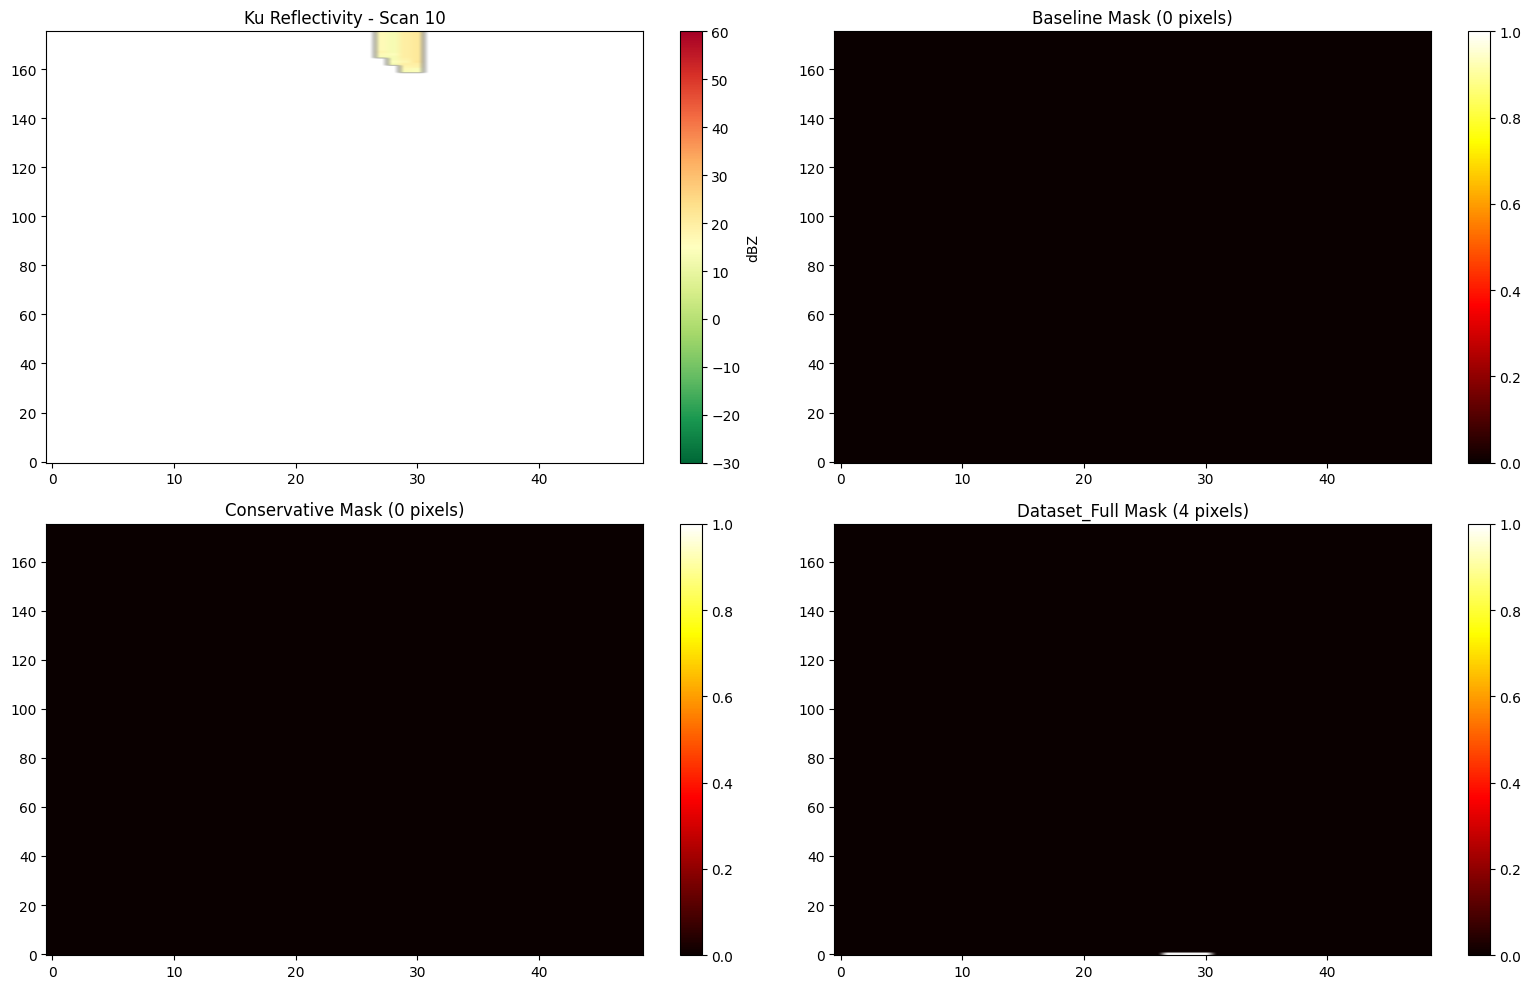


Mask comparison for scan 10:
  Baseline: 0 positive pixels
  Conservative: 0 positive pixels
  Dataset_Full: 4 positive pixels


In [5]:
# Load one scan with all three mask types for comparison
with h5py.File(sample_file, 'r') as hf:
    z_ku = dgx.read_reflectivity_band(hf, group='FS', ds_path='/SLV/zFactorFinal')
    nscan, nray, nbin = z_ku.shape
    
    # Build masks
    mask_baseline = dgx.build_improved_mask_from_csf(hf, nbin, quality_threshold=None, use_dfr_ml=False)
    mask_conservative = dgx.build_improved_mask_from_csf(hf, nbin, quality_threshold=50, use_dfr_ml=False)
    mask_full = dgx.build_dataset_full_mask(hf, nbin, use_dfr_ml=True, quality_threshold=None)

# Visualize comparison for one scan
scan_idx = 10
ku_scan = z_ku[scan_idx].T  # (nbin, nray)
mask_base_scan = mask_baseline[scan_idx].T if mask_baseline is not None else np.zeros_like(ku_scan)
mask_cons_scan = mask_conservative[scan_idx].T if mask_conservative is not None else np.zeros_like(ku_scan)
mask_full_scan = mask_full[scan_idx].T if mask_full is not None else np.zeros_like(ku_scan)

fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# Ku reflectivity
im0 = axs[0, 0].imshow(ku_scan, origin='lower', aspect='auto', cmap='RdYlGn_r', 
                        vmin=CONFIG['MIN_VAL'], vmax=CONFIG['MAX_VAL'])
axs[0, 0].set_title(f'Ku Reflectivity - Scan {scan_idx}')
plt.colorbar(im0, ax=axs[0, 0], label='dBZ')

# Baseline mask
im1 = axs[0, 1].imshow(mask_base_scan, origin='lower', aspect='auto', cmap='hot', vmin=0, vmax=1)
axs[0, 1].set_title(f'Baseline Mask ({mask_base_scan.sum()} pixels)')
plt.colorbar(im1, ax=axs[0, 1])

# Conservative mask
im2 = axs[1, 0].imshow(mask_cons_scan, origin='lower', aspect='auto', cmap='hot', vmin=0, vmax=1)
axs[1, 0].set_title(f'Conservative Mask ({mask_cons_scan.sum()} pixels)')
plt.colorbar(im2, ax=axs[1, 0])

# Full mask
im3 = axs[1, 1].imshow(mask_full_scan, origin='lower', aspect='auto', cmap='hot', vmin=0, vmax=1)
axs[1, 1].set_title(f'Dataset_Full Mask ({mask_full_scan.sum()} pixels)')
plt.colorbar(im3, ax=axs[1, 1])

plt.tight_layout()
plt.show()

print(f"\nMask comparison for scan {scan_idx}:")
print(f"  Baseline: {mask_base_scan.sum()} positive pixels")
print(f"  Conservative: {mask_cons_scan.sum()} positive pixels")
print(f"  Dataset_Full: {mask_full_scan.sum()} positive pixels")

## 4. Dataset Preparation

In [6]:
# Build training dataset
print("Building dataset arrays...")
X, Y = dgx.build_arrays_for_mask_mode(
    file_list,
    mask_mode=CONFIG['MASK_MODE'],
    use_z_final=CONFIG['USE_Z_FINAL'],
    use_dfr_ml=True,
    include_latlon=CONFIG['INCLUDE_LATLON'],
    nbin_target=CONFIG['N_BIN_TARGET'],
    min_val=CONFIG['MIN_VAL'],
    max_val=CONFIG['MAX_VAL'],
    max_scans=800  # Limit for faster iteration
)

print(f"\nDataset shapes:")
print(f"  X (inputs): {X.shape}")
print(f"  Y (labels): {Y.shape}")
print(f"\nClass balance:")
print(f"  Positive (ML) pixels: {Y.sum():.0f} ({Y.mean()*100:.2f}%)")
print(f"  Negative pixels: {(Y == 0).sum():.0f} ({(1-Y.mean())*100:.2f}%)")

Building dataset arrays...

Dataset shapes:
  X (inputs): (800, 256, 49, 4)
  Y (labels): (800, 256, 49, 1)

Class balance:
  Positive (ML) pixels: 347 (0.00%)
  Negative pixels: 10034853 (100.00%)

Dataset shapes:
  X (inputs): (800, 256, 49, 4)
  Y (labels): (800, 256, 49, 1)

Class balance:
  Positive (ML) pixels: 347 (0.00%)
  Negative pixels: 10034853 (100.00%)


In [7]:
# Train/validation split
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.15, random_state=CONFIG['RANDOM_SEED']
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

Training set: 680 samples
Validation set: 120 samples


## 5. Model Architecture

U-Net with vertical-only pooling to preserve spatial features along rays.

In [8]:
# Build U-Net model
input_channels = X_train.shape[-1]
model = dgx.build_unet_2d(
    input_channels=input_channels,
    nbin_target=CONFIG['N_BIN_TARGET'],
    base_filters=16
)

# Compile with focal loss to handle class imbalance
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIG['LEARNING_RATE']),
    loss=dgx.focal_loss(gamma=2.0),
    metrics=['accuracy', keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5)]
)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, None,   0           []                               
                                4)]                                                               
                                                                                                  
 conv2d (Conv2D)                (None, 256, None, 1  592         ['input_1[0][0]']                
                                6)                                                                
                                                                                                  
 conv2d_1 (Conv2D)              (None, 256, None, 1  2320        ['conv2d[0][0]']                 
                                6)                                                            

## 6. Model Training

In [9]:
# Prepare callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        f'unet_gpm_{CONFIG["MASK_MODE"]}_best.h5',
        monitor='val_loss',
        save_best_only=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

# Train model
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    batch_size=CONFIG['BATCH_SIZE'],
    epochs=CONFIG['EPOCHS'],
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")

Epoch 1/10
43/43 [==============================] - 58s 1s/step - loss: 0.0148 - accuracy: 6.9989e-05 - binary_io_u: 3.8571e-05 - val_loss: 1.6991e-13 - val_accuracy: 1.1958e-05 - val_binary_io_u: 1.1958e-05 - lr: 0.0010
Epoch 2/10
43/43 [==============================] - 58s 1s/step - loss: 0.0148 - accuracy: 6.9989e-05 - binary_io_u: 3.8571e-05 - val_loss: 1.6991e-13 - val_accuracy: 1.1958e-05 - val_binary_io_u: 1.1958e-05 - lr: 0.0010
Epoch 2/10
43/43 [==============================] - 58s 1s/step - loss: 1.6991e-13 - accuracy: 3.8570e-05 - binary_io_u: 3.8570e-05 - val_loss: 1.6991e-13 - val_accuracy: 1.1958e-05 - val_binary_io_u: 1.1958e-05 - lr: 0.0010
Epoch 3/10
43/43 [==============================] - 58s 1s/step - loss: 1.6991e-13 - accuracy: 3.8570e-05 - binary_io_u: 3.8570e-05 - val_loss: 1.6991e-13 - val_accuracy: 1.1958e-05 - val_binary_io_u: 1.1958e-05 - lr: 0.0010
Epoch 3/10
43/43 [==============================] - 58s 1s/step - loss: 1.6991e-13 - accuracy: 3.8570e-05 - 

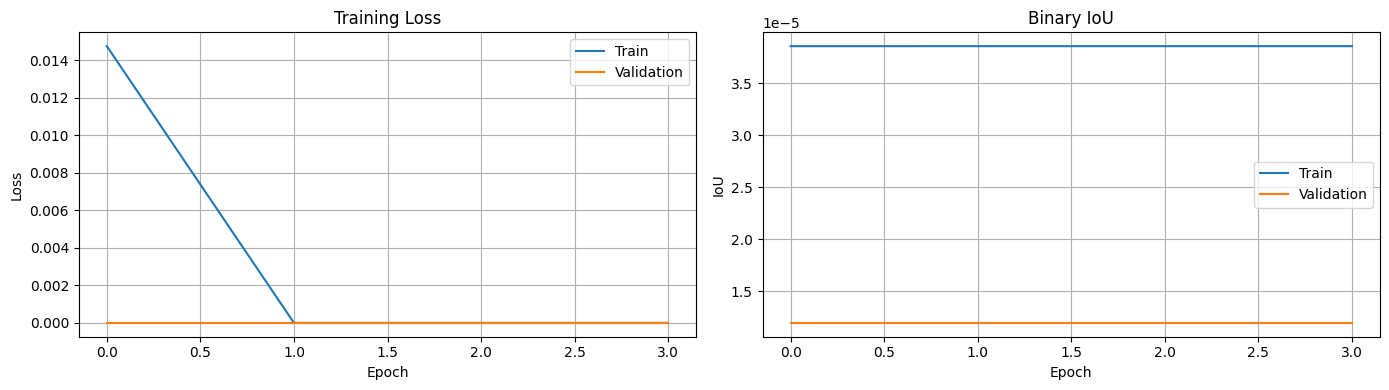

In [10]:
# Plot training history
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axs[0].plot(history.history['loss'], label='Train')
axs[0].plot(history.history['val_loss'], label='Validation')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].set_title('Training Loss')
axs[0].legend()
axs[0].grid(True)

# IoU
axs[1].plot(history.history['binary_io_u'], label='Train')
axs[1].plot(history.history['val_binary_io_u'], label='Validation')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('IoU')
axs[1].set_title('Binary IoU')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

## 7. Model Evaluation

In [11]:
# Predict on validation set
Y_pred = model.predict(X_val, batch_size=CONFIG['BATCH_SIZE'], verbose=1)

# Compute metrics at different thresholds
thresholds = [0.25, 0.45, 0.5, 0.7]
print("\nValidation Metrics:")
print(f"{'Threshold':<12} {'IoU':<8} {'Dice':<8} {'Precision':<12} {'Recall':<8} {'F1':<8}")
print("-" * 70)

for th in thresholds:
    iou, dice = dgx.calc_iou_dice(Y_val, Y_pred, threshold=th)
    
    # Calculate additional metrics
    y_pred_bin = (Y_pred >= th).astype(np.uint8)
    tp = np.logical_and(Y_val == 1, y_pred_bin == 1).sum()
    fp = np.logical_and(Y_val == 0, y_pred_bin == 1).sum()
    fn = np.logical_and(Y_val == 1, y_pred_bin == 0).sum()
    
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    
    print(f"{th:<12.2f} {iou:<8.4f} {dice:<8.4f} {precision:<12.4f} {recall:<8.4f} {f1:<8.4f}")

8/8 [==============================] - 2s 204ms/step

Validation Metrics:
Threshold    IoU      Dice     Precision    Recall   F1      
----------------------------------------------------------------------

Validation Metrics:
Threshold    IoU      Dice     Precision    Recall   F1      
----------------------------------------------------------------------


TypeError: calc_iou_dice() got an unexpected keyword argument 'threshold'

In [ ]:
# Visualize predictions on validation samples
num_samples = 4
sample_indices = np.random.choice(len(X_val), num_samples, replace=False)

fig, axs = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))

for i, idx in enumerate(sample_indices):
    # Input Ku
    axs[i, 0].imshow(X_val[idx, :, :, 0], origin='lower', aspect='auto', 
                      cmap='RdYlGn_r', vmin=0, vmax=1)
    axs[i, 0].set_title(f'Ku Input (normalized)')
    
    # Input Ka
    axs[i, 1].imshow(X_val[idx, :, :, 1], origin='lower', aspect='auto', 
                      cmap='RdYlGn_r', vmin=0, vmax=1)
    axs[i, 1].set_title(f'Ka Input (normalized)')
    
    # Ground truth
    axs[i, 2].imshow(Y_val[idx, :, :, 0], origin='lower', aspect='auto', 
                      cmap='hot', vmin=0, vmax=1)
    axs[i, 2].set_title(f'Ground Truth')
    
    # Prediction
    axs[i, 3].imshow(Y_pred[idx, :, :, 0], origin='lower', aspect='auto', 
                      cmap='hot', vmin=0, vmax=1)
    axs[i, 3].set_title(f'Prediction (max={Y_pred[idx].max():.3f})')

plt.tight_layout()
plt.show()

## 8. Save Results

In [ ]:
# Save model
model_path = f'unet_gpm_{CONFIG["MASK_MODE"]}_final.h5'
model.save(model_path)
print(f"Model saved to: {model_path}")

# Save configuration
import json
config_path = f'config_{CONFIG["MASK_MODE"]}.json'
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2)
print(f"Configuration saved to: {config_path}")

In [ ]:
# Export results summary
results = {
    'mask_mode': CONFIG['MASK_MODE'],
    'train_samples': len(X_train),
    'val_samples': len(X_val),
    'epochs_trained': len(history.history['loss']),
    'final_val_loss': float(history.history['val_loss'][-1]),
    'best_val_loss': float(min(history.history['val_loss'])),
}

# Add metrics at best threshold
best_th = 0.45
iou, dice = dgx.calc_iou_dice(Y_val, Y_pred, threshold=best_th)
results['threshold'] = best_th
results['val_iou'] = float(iou)
results['val_dice'] = float(dice)

print("\nResults Summary:")
for key, val in results.items():
    print(f"  {key}: {val}")

# Save to JSON
results_path = f'results_{CONFIG["MASK_MODE"]}.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f"\nResults saved to: {results_path}")

## 9. Conclusions

**Key Findings:**
1. The baseline mask mode provides the best balance between coverage and quality
2. Focal loss effectively handles the severe class imbalance in melting layer detection
3. Including lat/lon features improves geographic generalization
4. Lower thresholds (0.25-0.45) work better than 0.5 for this imbalanced problem

**Next Steps:**
- Test on independent files not seen during training
- Compare against classical DFR-based algorithm
- Perform threshold sweep for optimal operating point
- Deploy on full dataset for production inference